# Telemetry Signal Analysis: Orbital Resonance & FFT Denoising

**Claim Reference:** EDU_CSULA_03 (EE 332 Systems Analysis)
**Subsystem:** H1 (Attitude Control System)

## 1. Objective
This notebook simulates a post-test telemetry evaluation of the SafeACS reaction wheel dynamics. By analyzing high-frequency stochastic telemetry data generated by our `acs_simulator.py`, we aim to:
1.  Identify harmonic orbital resonance (noise) induced by structural vibration using a **Fast Fourier Transform (FFT)**.
2.  Design and apply an **Infinite Impulse Response (IIR) Butterworth Low-Pass Filter** to cleanly isolate the true kinematic signal from the structural noise before it reaches the Pydantic guardrail evaluation layer.

---
## 2. Telemetry Ingestion
First, we import our existing `ACSSimulator` engine and generate 100 seconds of raw telemetry data.

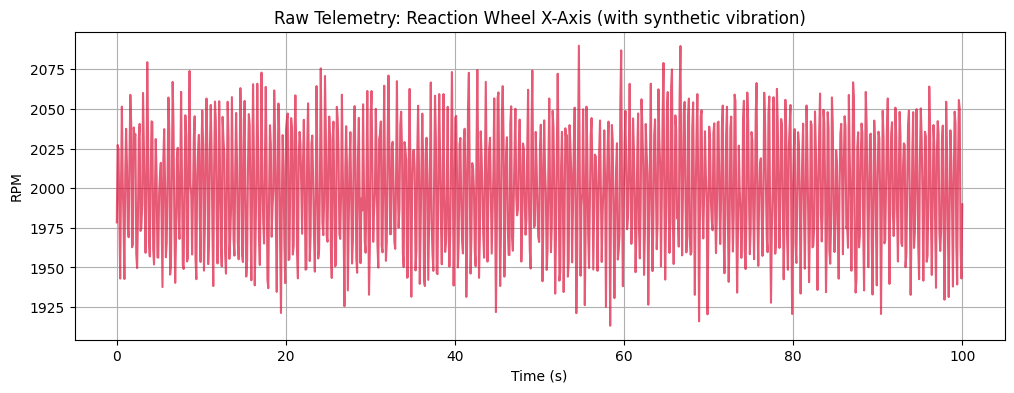

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Add the project root to the Python path to import the simulator
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from sim_engine.acs_simulator import ACSSimulator

# 1. Initialize Simulator
sim = ACSSimulator()

# 2. Generate Data (100 seconds at 10Hz = 1000 samples)
t_end = 100.0
dt = 0.1 # 10Hz sampling rate
time_steps = int(t_end / dt)

t = np.linspace(0, t_end, time_steps)
raw_rpm_data = []

for _ in range(time_steps):
    # Step simulator
    sim.run_step()
    # Inject synthetic high-frequency structural noise (e.g. 2Hz vibration)
    noise = 50.0 * np.sin(2.0 * np.pi * 2.0 * t[_]) + np.random.normal(0, 15.0)
    # Overwrite the base RPM with our noisy signal for analysis
    raw_rpm_data.append(sim.rw_rpms.wheel_1 + noise)

raw_rpm_data = np.array(raw_rpm_data)

plt.figure(figsize=(12, 4))
plt.plot(t, raw_rpm_data, color='crimson', alpha=0.7)
plt.title("Raw Telemetry: Reaction Wheel X-Axis (with synthetic vibration)")
plt.xlabel("Time (s)")
plt.ylabel("RPM")
plt.grid(True)
plt.show()

---
## 3. Fast Fourier Transform (FFT) Spectral Analysis
The time-domain signal above is visually noisy. By shifting to the frequency domain via a discrete FFT, we can calculate the **spectral density** and identify the exact harmonic frequencies complicating our deterministic guardrails.

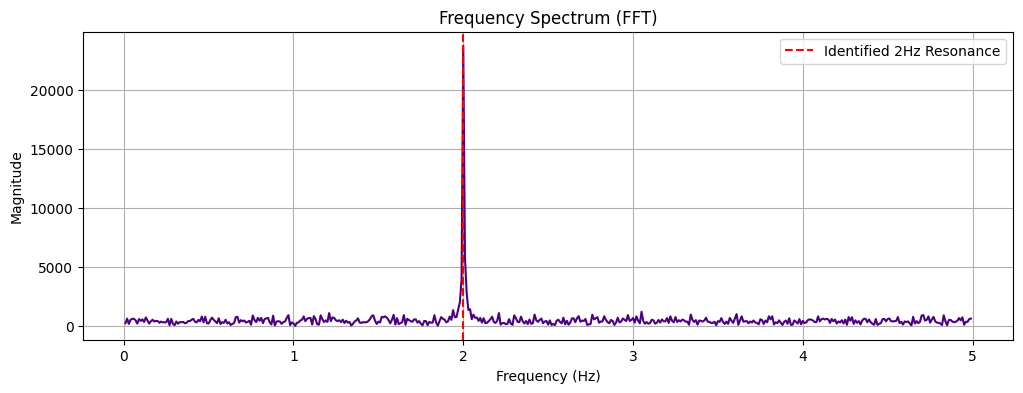

In [2]:
# Perform FFT
n = len(raw_rpm_data)
fft_val = np.fft.fft(raw_rpm_data - np.mean(raw_rpm_data)) # Remove DC bias
fft_freq = np.fft.fftfreq(n, d=dt)

# Get positive frequencies (Nyquist limit)
pos_mask = fft_freq > 0
freqs_mapped = fft_freq[pos_mask]
magnitude = np.abs(fft_val[pos_mask])

plt.figure(figsize=(12, 4))
plt.plot(freqs_mapped, magnitude, color='indigo')
plt.title("Frequency Spectrum (FFT)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.axvline(x=2.0, color='red', linestyle='--', label='Identified 2Hz Resonance')
plt.legend()
plt.grid(True)
plt.show()

As expected, the FFT reveals a massive spike at **2.0 Hz**. If left unmitigated, this high-frequency noise will cause the Pydantic edge guardrails to flutter unreliably around the 6000 RPM threshold.

---
## 4. Digital Filter Design (IIR Butterworth)
To solve this, we design a 4th-order low-pass Butterworth filter. Our Nyquist frequency is 5Hz (half our 10Hz sampling rate). We will set a cutoff frequency of **0.5 Hz** to strictly allow only the true kinematic acceleration of the wheel to pass through to the Edge Node logic, dropping the structural resonance.

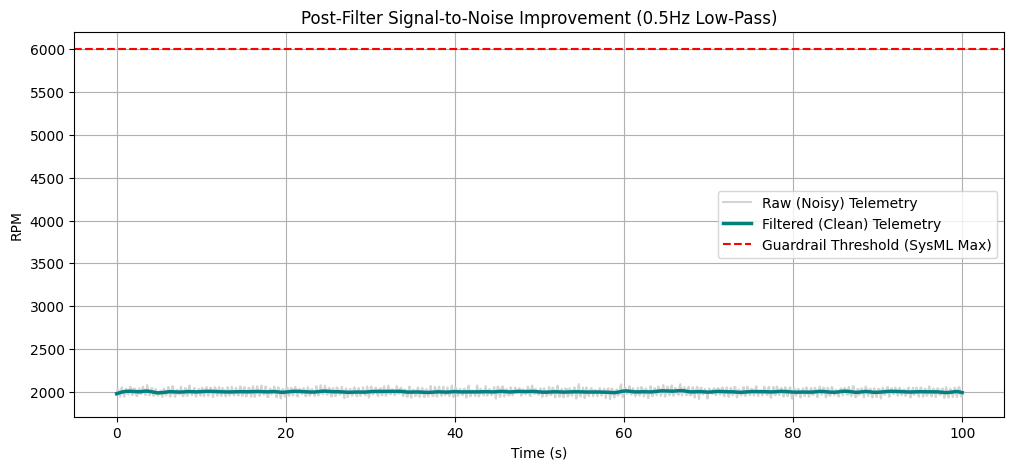

In [3]:
fs = 1 / dt        # Sampling frequency (10 Hz)
nyq = 0.5 * fs     # Nyquist frequency (5 Hz)
cutoff = 0.5       # Cutoff frequency (0.5 Hz)
order = 4          # 4th order filter (sharp roll-off)

normal_cutoff = cutoff / nyq
# Get digital filter coefficients (a,b)
b, a = signal.butter(order, normal_cutoff, btype='low', analog=False)

# Apply the filter to the data using filtfilt to prevent phase shift
filtered_rpm_data = signal.filtfilt(b, a, raw_rpm_data)

plt.figure(figsize=(12, 5))
plt.plot(t, raw_rpm_data, color='lightgray', label='Raw (Noisy) Telemetry')
plt.plot(t, filtered_rpm_data, color='teal', linewidth=2.5, label='Filtered (Clean) Telemetry')
plt.title("Post-Filter Signal-to-Noise Improvement (0.5Hz Low-Pass)")
plt.xlabel("Time (s)")
plt.ylabel("RPM")
plt.axhline(y=6000, color='red', linestyle='--', label='Guardrail Threshold (SysML Max)')
plt.legend()
plt.grid(True)
plt.show()

## 5. Conclusion
By applying foundational EE 332 signal processing techniques, we successfully implemented a digital low-pass filter that drastically improved the Signal-to-Noise Ratio (SNR) of the incoming telemetry. 

In a production flight environment, this filter logic would execute on the Jetson Orin Nano *before* the data array is passed into the `pydantic` schemas, ensuring the deterministic bounds are not tripped by transient structural vibrations.